# Logistic Regression from Scratch

Logistic regression is a classifier, despite the name. It takes the same linear score a regression
model would produce and squashes it into a probability.

**Why linear regression is the wrong tool here.** A linear model outputs

$$z = \mathbf{w}^\top\mathbf{x} + b$$

which is unbounded - it runs from $-\infty$ to $+\infty$. A probability has to lie in $[0, 1]$. Fit
a straight line to 0/1 labels and it will predict $1.7$ for a confident positive and $-0.4$ for a
confident negative, neither of which means anything. Worse, a single extreme point drags the line
and moves the threshold for every other sample.

## The sigmoid

The fix is to pass $z$ through a function that maps the whole real line into $(0, 1)$. The
**logistic** or **sigmoid** function does exactly that:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

and the model becomes

$$p = P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top\mathbf{x} + b)$$

Its properties:

- $z \to +\infty \Rightarrow e^{-z} \to 0 \Rightarrow \sigma \to 1$
- $z \to -\infty \Rightarrow e^{-z} \to \infty \Rightarrow \sigma \to 0$
- $\sigma(0) = 1/(1+1) = 0.5$, so the decision boundary $p = 0.5$ is exactly the plane
  $\mathbf{w}^\top\mathbf{x} + b = 0$ - a straight line, which is why this is a *linear* classifier
- $\sigma(-z) = 1 - \sigma(z)$, so the two classes are treated symmetrically

**The derivative.** Write $\sigma = (1 + e^{-z})^{-1}$ and differentiate with the chain rule:

$$\sigma'(z) = -(1 + e^{-z})^{-2}\cdot(-e^{-z}) = \frac{e^{-z}}{(1 + e^{-z})^{2}}$$

Split that product apart:

$$\sigma'(z) = \frac{1}{1 + e^{-z}}\cdot\frac{e^{-z}}{1 + e^{-z}}
            = \sigma(z)\cdot\frac{(1 + e^{-z}) - 1}{1 + e^{-z}}
            = \sigma(z)\bigl(1 - \sigma(z)\bigr)$$

So

$$\sigma'(z) = \sigma(z)\bigl(1 - \sigma(z)\bigr)$$

That identity is what makes the gradient below come out as cleanly as it does.

## The logit, and where the name comes from

Rearranging $p = 1/(1 + e^{-z})$ for $z$:

$$\frac{1}{p} = 1 + e^{-z} \;\Rightarrow\; e^{-z} = \frac{1-p}{p}
  \;\Rightarrow\; z = \log\frac{p}{1-p}$$

so

$$\log\frac{p}{1-p} = \mathbf{w}^\top\mathbf{x} + b$$

The quantity $p/(1-p)$ is the **odds** and its logarithm is the **log-odds** or **logit**. The
model is linear in the log-odds, not in the probability. That gives the coefficients a direct
reading: increasing $x_j$ by one unit adds $w_j$ to the log-odds, i.e. multiplies the odds by
$e^{w_j}$, whatever the other features are.

## Binary cross-entropy

Each sample is a Bernoulli draw with probability $p_i$, so the likelihood of the data is
$\prod_i p_i^{y_i}(1-p_i)^{1-y_i}$. Taking the negative log and averaging gives the loss:

$$J = -\frac{1}{n}\sum_{i=1}^{n}\Bigl[y_i \log p_i + (1 - y_i)\log(1 - p_i)\Bigr]$$

For a positive sample only $\log p_i$ survives, for a negative one only $\log(1-p_i)$. Either way
the penalty goes to $+\infty$ as the model becomes confidently wrong, which is the behaviour we
want.

**Why not squared error.** $J = \frac{1}{n}\sum (y_i - \sigma(z_i))^2$ is a perfectly valid thing
to write down, but composed with the sigmoid it is **non-convex** in $\mathbf{w}$ and $b$, so
gradient descent can settle into a local minimum. It also multiplies the gradient by
$\sigma'(z) = \sigma(1-\sigma)$, which is near zero exactly when the model is confidently wrong -
so the worst mistakes produce the smallest updates and learning stalls. Log loss is convex and has
neither problem.

## The gradient

Take one sample and differentiate $J_i = -[y\log p + (1-y)\log(1-p)]$ with respect to $z$, where
$p = \sigma(z)$:

$$\frac{\partial J_i}{\partial p} = -\frac{y}{p} + \frac{1-y}{1-p}
  = \frac{p - y}{p(1-p)}$$

$$\frac{\partial p}{\partial z} = \sigma'(z) = p(1-p)$$

$$\frac{\partial J_i}{\partial z}
  = \frac{p - y}{p(1-p)}\cdot p(1-p) = p - y$$

The $p(1-p)$ from the sigmoid's derivative cancels against the denominator produced by the log.
**That cancellation is the whole reason the sigmoid and log loss are paired.** What is left is just
the error. Since $z = \mathbf{w}^\top\mathbf{x} + b$ gives $\partial z/\partial \mathbf{w} =
\mathbf{x}$ and $\partial z/\partial b = 1$, averaging over the dataset:

$$\nabla_{\mathbf{w}} J = \frac{1}{n}X^\top(\mathbf{p} - \mathbf{y}),
  \qquad \frac{\partial J}{\partial b} = \frac{1}{n}\sum_{i=1}^{n} (p_i - y_i)$$

This is **identical in form** to the least-squares gradient of linear regression, with the
predicted value replaced by the predicted probability.

## Gradient descent

There is no closed form for $\mathbf{w}$ here, so the parameters are found iteratively:

$$\theta \leftarrow \theta - \alpha\,\nabla_\theta J$$

$\alpha$ is the learning rate. Too small and it takes far too many iterations; too large and the
steps overshoot the minimum and the loss oscillates or diverges. Because $J$ is convex there is a
single global minimum, so given a sensible $\alpha$ the starting point does not matter.

This notebook covers both cases:

- **Part 1** - two classes, sigmoid, binary cross-entropy, on UCI Banknote Authentication.
- **Part 2** - more than two classes, softmax, categorical cross-entropy, on UCI Iris.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

BLUE = '#2a78d6'
ORANGE = '#eb6834'
AQUA = '#1baf7a'

np.random.seed(42)

## The sigmoid function

`sigmoid` computes $\sigma(z) = 1/(1 + e^{-z})$. The naive form overflows for large negative `z`,
because `np.exp(-z)` then explodes, so the cell splits on the sign: for $z \ge 0$ it uses
$1/(1+e^{-z})$ and for $z < 0$ the algebraically identical $e^{z}/(1+e^{z})$. In both branches the
exponent is negative, so `np.exp` never overflows.

The plot draws $\sigma(z)$ over $z \in [-10, 10]$ next to its derivative
$\sigma(z)(1 - \sigma(z))$. The left panel marks the two asymptotes at 0 and 1 and the crossing
point $\sigma(0) = 0.5$, which is the decision threshold. The right panel shows the derivative
peaking at $z = 0$ with value $0.25$ and falling to zero in both tails - the sigmoid is flat out
there, so a confidently-placed sample produces almost no change in $p$ when $z$ moves.

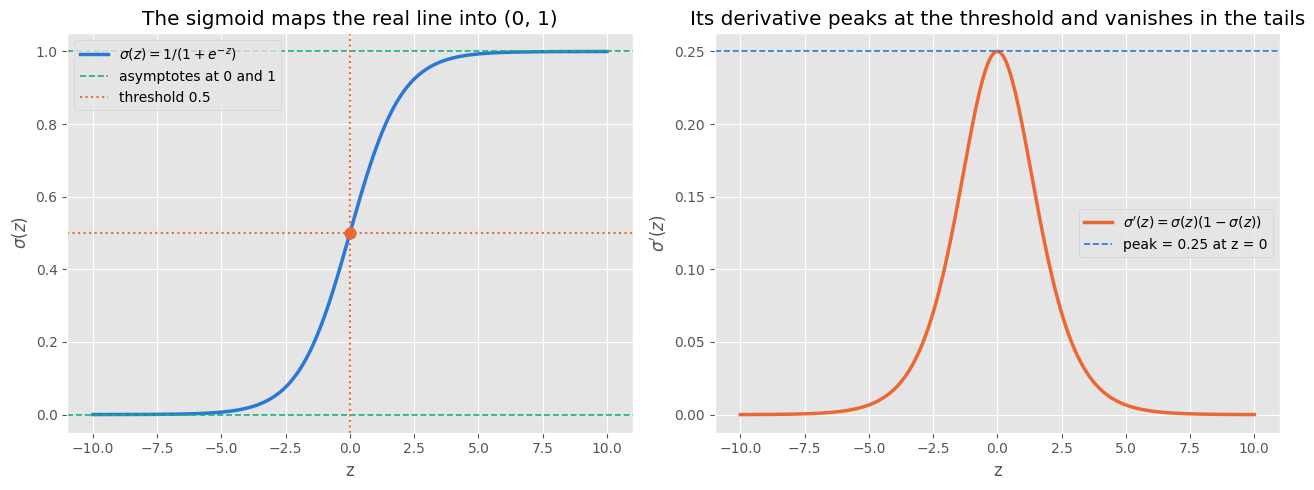

sigmoid(0)   = 0.5
sigmoid(-6)  = 0.002473
sigmoid(6)   = 0.997527
sigmoid(-800) does not overflow: 0.0
symmetry  sigmoid(-2) == 1 - sigmoid(2): True


In [2]:
def sigmoid(z):
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])          # z < 0, so this cannot overflow
    out[~pos] = ez / (1.0 + ez)
    return out


z = np.linspace(-10, 10, 400)
s = sigmoid(z)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(z, s, color=BLUE, linewidth=2.5, label=r'$\sigma(z) = 1/(1+e^{-z})$')
ax[0].axhline(1.0, color=AQUA, linestyle='--', linewidth=1.2, label='asymptotes at 0 and 1')
ax[0].axhline(0.0, color=AQUA, linestyle='--', linewidth=1.2)
ax[0].axhline(0.5, color=ORANGE, linestyle=':', linewidth=1.5, label='threshold 0.5')
ax[0].axvline(0.0, color=ORANGE, linestyle=':', linewidth=1.5)
ax[0].scatter([0], [0.5], color=ORANGE, s=70, zorder=5)
ax[0].set_xlabel('z')
ax[0].set_ylabel(r'$\sigma(z)$')
ax[0].set_title('The sigmoid maps the real line into (0, 1)')
ax[0].legend(loc='upper left')

ax[1].plot(z, s * (1 - s), color=ORANGE, linewidth=2.5,
           label=r"$\sigma'(z) = \sigma(z)(1-\sigma(z))$")
ax[1].axhline(0.25, color=BLUE, linestyle='--', linewidth=1.2, label='peak = 0.25 at z = 0')
ax[1].set_xlabel('z')
ax[1].set_ylabel(r"$\sigma'(z)$")
ax[1].set_title('Its derivative peaks at the threshold and vanishes in the tails')
ax[1].legend()

plt.tight_layout()
plt.show()

print('sigmoid(0)   =', sigmoid(0.0))
print('sigmoid(-6)  =', round(float(sigmoid(-6.0)), 6))
print('sigmoid(6)   =', round(float(sigmoid(6.0)), 6))
print('sigmoid(-800) does not overflow:', float(sigmoid(-800.0)))
print('symmetry  sigmoid(-2) == 1 - sigmoid(2):',
      np.isclose(float(sigmoid(-2.0)), 1 - float(sigmoid(2.0))))

# Part 1 - Binary classification with the sigmoid

## Loading the banknote data

The cell downloads UCI Banknote Authentication: 1372 banknotes photographed and passed through a
wavelet transform, leaving four continuous features - `variance`, `skewness`, `curtosis` and
`entropy` of the transformed image. The target `class` is 0 for genuine and 1 for forged. There
are no missing values, so nothing needs dropping, and the split is 762 against 610, which is close
enough to even that accuracy is a fair measure.

In [3]:
banknote = fetch_ucirepo(id=267)

feature_names = list(banknote.data.features.columns)
X_all = banknote.data.features.values.astype(float)
y_all = banknote.data.targets.values.ravel().astype(int)

print('rows:    ', X_all.shape[0])
print('features:', feature_names)
print()
print('genuine (0):', (y_all == 0).sum())
print('forged (1): ', (y_all == 1).sum())
print('missing values:', int(np.isnan(X_all).sum()))
print()
print('feature means: ', np.round(X_all.mean(axis=0), 3))
print('feature stdevs:', np.round(X_all.std(axis=0), 3))

rows:     1372
features: ['variance', 'skewness', 'curtosis', 'entropy']

genuine (0): 762
forged (1):  610
missing values: 0

feature means:  [ 0.434  1.922  1.398 -1.192]
feature stdevs: [2.842 5.867 4.308 2.1  ]


## The dataset at a glance

Three panels. The first is the class balance, giving the baseline a model has to beat: always
guessing "genuine" scores 55.5%. The second and third overlay the histograms of `variance` and
`skewness` split by class. `variance` on its own separates the two groups almost completely, which
is why it is the feature used for the single-feature model below; `skewness` overlaps far more.

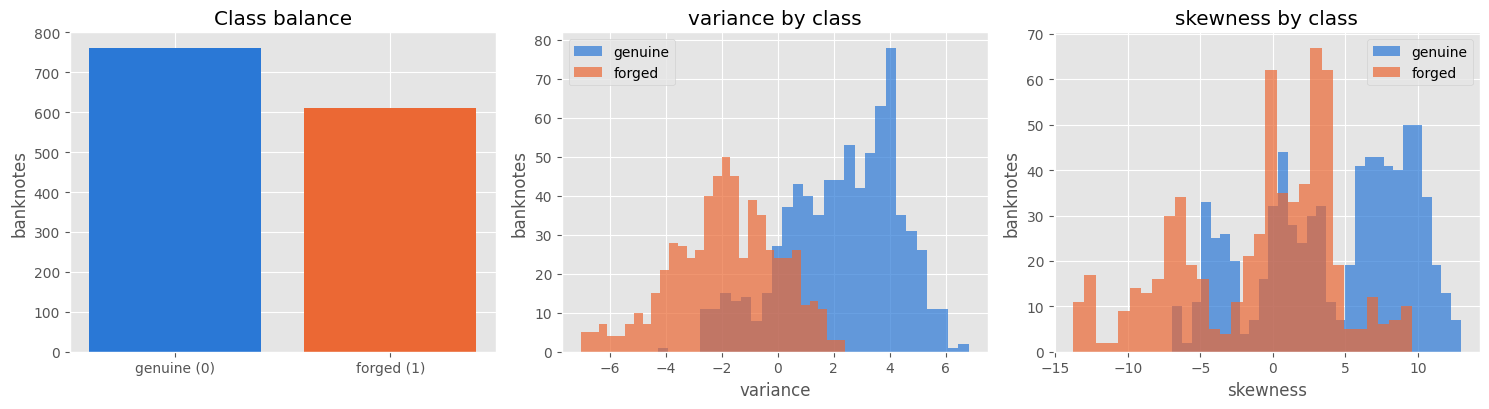

always-guess-genuine baseline: 0.5554


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

ax[0].bar(['genuine (0)', 'forged (1)'], [(y_all == 0).sum(), (y_all == 1).sum()],
          color=[BLUE, ORANGE])
ax[0].set_ylabel('banknotes')
ax[0].set_title('Class balance')

for col, panel in [(0, ax[1]), (1, ax[2])]:
    panel.hist(X_all[y_all == 0, col], bins=30, color=BLUE, alpha=0.7, label='genuine')
    panel.hist(X_all[y_all == 1, col], bins=30, color=ORANGE, alpha=0.7, label='forged')
    panel.set_xlabel(feature_names[col])
    panel.set_ylabel('banknotes')
    panel.set_title(f'{feature_names[col]} by class')
    panel.legend()

plt.tight_layout()
plt.show()

print('always-guess-genuine baseline:', round((y_all == 0).mean(), 4))

## Train/test split and standardisation

`rng.permutation` shuffles the row indices with a fixed seed and the first 75% become the training
set, the rest the test set.

The features are then standardised to $x' = (x - \mu)/s$. Gradient descent needs this: the four
columns span different ranges, and a shared learning rate that suits one of them will be far too
large or far too small for another, producing the long narrow valley that makes descent zig-zag.
`mu` and `sd` are computed **from the training rows only** and then applied to both sets. Using the
full dataset's statistics would leak information about the test rows into training.

In [5]:
rng = np.random.RandomState(42)
order = rng.permutation(len(X_all))
cut = int(0.75 * len(X_all))
train_idx, test_idx = order[:cut], order[cut:]

X_train_raw, X_test_raw = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

# training statistics only
mu = X_train_raw.mean(axis=0)
sd = X_train_raw.std(axis=0)

X_train = (X_train_raw - mu) / sd
X_test = (X_test_raw - mu) / sd

print('train:', X_train.shape, ' test:', X_test.shape)
print('train class counts:', (y_train == 0).sum(), (y_train == 1).sum())
print('test class counts: ', (y_test == 0).sum(), (y_test == 1).sum())
print()
print('standardised train means:', np.round(X_train.mean(axis=0), 6))
print('standardised train stdev:', np.round(X_train.std(axis=0), 6))
print('test means (not exactly 0, as expected):', np.round(X_test.mean(axis=0), 4))

train: (1029, 4)  test: (343, 4)
train class counts: 584 445
test class counts:  178 165

standardised train means: [ 0. -0. -0.  0.]
standardised train stdev: [1. 1. 1. 1.]
test means (not exactly 0, as expected): [-0.1467 -0.0898  0.103   0.0852]


## The Logistic_Regression class

`fit` runs full-batch gradient descent for `n_iter` steps. Each iteration:

- `z = X @ self.w + self.b` is the linear score for every row at once
- `p = sigmoid(z)` turns those scores into probabilities
- `self.loss(y, p)` records the current binary cross-entropy in `self.history`
- `error = p - y` is the gradient with respect to `z`, which is all the derivation left behind
- `self.w -= self.lr * (X.T @ error) / n` applies
  $\nabla_{\mathbf{w}} J = \frac{1}{n}X^\top(\mathbf{p} - \mathbf{y})$
- `self.b -= self.lr * error.mean()` applies $\partial J/\partial b = \frac{1}{n}\sum_i(p_i - y_i)$

`self.w` starts at zeros rather than random values. The loss is convex, so there is one global
minimum and the starting point only affects how long it takes to get there.

`loss` clips `p` away from 0 and 1 by `1e-12` before taking the logarithm. Without that, a
perfectly confident and correct prediction produces $\log(0)$ and the loss becomes `nan`. The
banknote data is close to linearly separable, so this actually happens.

`predict_proba` returns $\sigma(\mathbf{w}^\top\mathbf{x} + b)$ and `predict` thresholds it at
0.5. `decision_function` returns the raw score $z$, which is positive exactly when $p > 0.5$ and is
what the boundary is drawn from.

In [6]:
class Logistic_Regression:
    def __init__(self, lr=0.1, n_iter=3000):
        self.lr = lr
        self.n_iter = n_iter

    def loss(self, y, p):
        p = np.clip(p, 1e-12, 1 - 1e-12)
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
        self.history = []

        for _ in range(self.n_iter):
            p = sigmoid(X @ self.w + self.b)
            self.history.append(self.loss(y, p))

            error = p - y
            self.w -= self.lr * (X.T @ error) / n
            self.b -= self.lr * error.mean()

        self.history = np.array(self.history)
        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict_proba(self, X):
        return sigmoid(self.decision_function(X))

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

## One feature, so the S-curve can be drawn

`variance` alone separates the classes fairly well, and with a single feature the fitted model is a
curve in the plane and can be plotted directly over the labels. The cell slices column 0 out of the
standardised matrices, keeping the 2-D shape `(n, 1)` that `fit` expects, trains for 3000
iterations at `lr=0.5`, and reports train and test accuracy alongside the fitted $w$ and $b$.

In [7]:
X_train_v = X_train[:, [0]]
X_test_v = X_test[:, [0]]

model_v = Logistic_Regression(lr=0.5, n_iter=3000).fit(X_train_v, y_train)

train_acc_v = (model_v.predict(X_train_v) == y_train).mean()
test_acc_v = (model_v.predict(X_test_v) == y_test).mean()

print('w =', np.round(model_v.w, 4), ' b =', round(model_v.b, 4))
print('final training loss:', round(float(model_v.history[-1]), 5))
print()
print('train accuracy:', round(train_acc_v, 4))
print('test accuracy: ', round(test_acc_v, 4))

# the boundary sits where w*x + b = 0
boundary_std = -model_v.b / model_v.w[0]
print()
print('p = 0.5 at standardised variance =', round(boundary_std, 4))
print('which is raw variance =', round(boundary_std * sd[0] + mu[0], 4))

w = [-2.8229]  b = -0.5767
final training loss: 0.33969

train accuracy: 0.8426
test accuracy:  0.8455

p = 0.5 at standardised variance = -0.2043
which is raw variance = -0.0447


## The fitted sigmoid over the data

The plot draws the training labels as points at $y = 0$ and $y = 1$, jittered vertically a little
so overlapping notes stay visible, and lays the fitted curve
$\sigma(w\,x + b)$ over them. The vertical line marks where the curve crosses 0.5, which is the
decision boundary: everything to the left of it is predicted forged, everything to the right
genuine.

The curve is steep because $w$ is large in magnitude - the classes barely overlap, so the model
switches from confident 0 to confident 1 over a narrow band. Where the two point clouds do overlap
the curve passes through the middle probabilities, which is the model reporting genuine
uncertainty rather than committing.

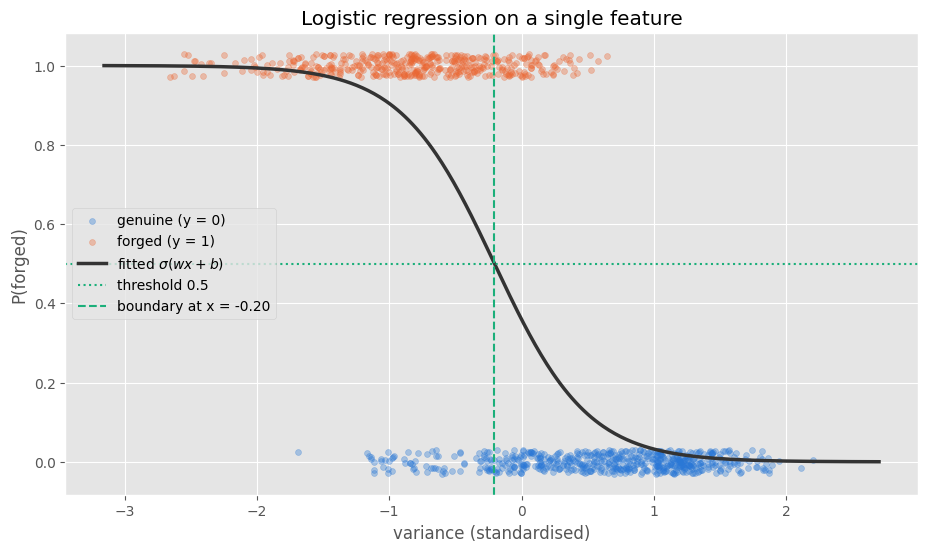

In [8]:
grid = np.linspace(X_train_v.min() - 0.5, X_train_v.max() + 0.5, 400).reshape(-1, 1)
curve = model_v.predict_proba(grid)

jitter = np.random.RandomState(0).uniform(-0.03, 0.03, len(y_train))

plt.figure(figsize=(11, 6))
plt.scatter(X_train_v[y_train == 0], y_train[y_train == 0] + jitter[y_train == 0],
            color=BLUE, alpha=0.35, s=18, label='genuine (y = 0)')
plt.scatter(X_train_v[y_train == 1], y_train[y_train == 1] + jitter[y_train == 1],
            color=ORANGE, alpha=0.35, s=18, label='forged (y = 1)')
plt.plot(grid, curve, color='#333333', linewidth=2.5, label=r'fitted $\sigma(wx + b)$')
plt.axhline(0.5, color=AQUA, linestyle=':', linewidth=1.5, label='threshold 0.5')
plt.axvline(boundary_std, color=AQUA, linestyle='--', linewidth=1.5,
            label=f'boundary at x = {boundary_std:.2f}')
plt.xlabel('variance (standardised)')
plt.ylabel('P(forged)')
plt.title('Logistic regression on a single feature')
plt.legend(loc='center left')
plt.show()

## All four features

The same class, now fitted on the full standardised `X_train`. Nothing in the code changes - `fit`
already works on any number of columns - only the shape of `self.w` does.

The cell prints the final loss, the train and test accuracy, and each coefficient next to
$e^{w_j}$, the factor by which the odds of "forged" are multiplied per one-standard-deviation
increase in that feature. All four coefficients are negative, so every feature pushes towards
"genuine" as it grows, and `variance` has by far the largest magnitude.

In [9]:
model = Logistic_Regression(lr=0.5, n_iter=3000).fit(X_train, y_train)

train_acc = (model.predict(X_train) == y_train).mean()
test_acc = (model.predict(X_test) == y_test).mean()

print('final training loss:', round(float(model.history[-1]), 6))
print('train accuracy:', round(train_acc, 4))
print('test accuracy: ', round(test_acc, 4))
print()
print('b =', round(model.b, 4))
print(f"{'feature':<10}{'w':>10}{'odds factor exp(w)':>22}")
for name, wj in zip(feature_names, model.w):
    print(f'{name:<10}{wj:>10.4f}{np.exp(wj):>22.4f}')

final training loss: 0.031986
train accuracy: 0.9883
test accuracy:  0.9825

b = -2.8116
feature            w    odds factor exp(w)
variance     -6.6557                0.0013
skewness     -7.4164                0.0006
curtosis     -6.7300                0.0012
entropy       0.1677                1.1826


## Loss against iteration

`self.history` holds the training loss after every step. The cell plots it on a linear axis and
again on a log axis. The linear plot shows the loss dropping steeply in the first few hundred
iterations and then flattening; the log axis shows it is still decreasing after that, just slowly.

It never reaches zero. The data is close to linearly separable, so the model can keep growing
$\lVert\mathbf{w}\rVert$ to push its probabilities further towards 0 and 1, and the loss keeps
creeping down without the decision boundary moving much. That is why plain unregularised logistic
regression on separable data has no finite optimum, and why a fixed iteration budget is a
reasonable stopping rule here.

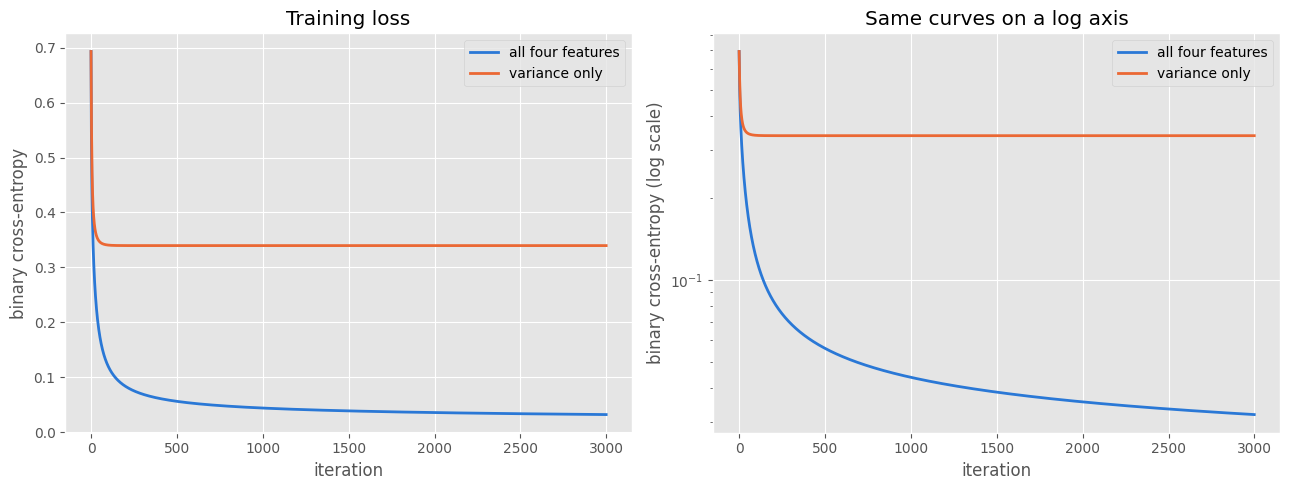

iteration    0: loss 0.693147
iteration   10: loss 0.362462
iteration  100: loss 0.119907
iteration  500: loss 0.056052
iteration 1000: loss 0.043849
iteration 2999: loss 0.031986


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(model.history, color=BLUE, linewidth=2, label='all four features')
ax[0].plot(model_v.history, color=ORANGE, linewidth=2, label='variance only')
ax[0].set_xlabel('iteration')
ax[0].set_ylabel('binary cross-entropy')
ax[0].set_title('Training loss')
ax[0].legend()

ax[1].plot(model.history, color=BLUE, linewidth=2, label='all four features')
ax[1].plot(model_v.history, color=ORANGE, linewidth=2, label='variance only')
ax[1].set_yscale('log')
ax[1].set_xlabel('iteration')
ax[1].set_ylabel('binary cross-entropy (log scale)')
ax[1].set_title('Same curves on a log axis')
ax[1].legend()

plt.tight_layout()
plt.show()

for i in [0, 10, 100, 500, 1000, 2999]:
    print(f'iteration {i:>4}: loss {model.history[i]:.6f}')

## Choosing the learning rate

The cell refits the four-feature model at five values of $\alpha$ and plots all five loss curves on
one set of axes.

Small $\alpha$ takes correspondingly small steps: at $0.001$ the curve is still nearly flat at the
top after 3000 iterations. Large $\alpha$ converges in far fewer iterations. Because the loss is
convex and its curvature here is mild, even $\alpha = 5$ is stable - it is the fastest of the five.
The failure mode of an over-large $\alpha$ is overshooting the minimum on every step so the loss
oscillates or diverges; the standardisation applied earlier is a large part of why that does not
happen at these values, since it keeps all four directions on a comparable scale.

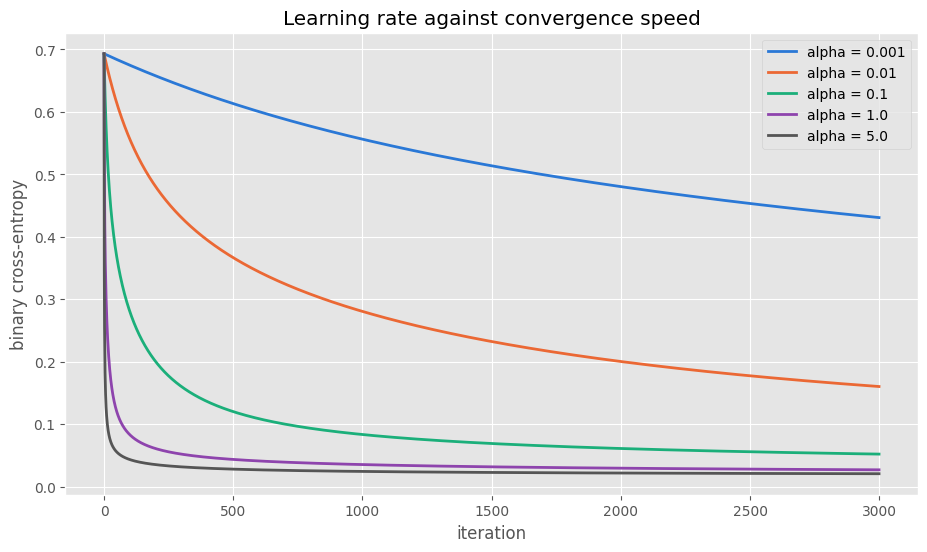

   alpha    final loss   test accuracy
   0.001      0.430906          0.8892
    0.01      0.160525          0.9650
     0.1      0.052374          0.9796
     1.0      0.027219          0.9854
     5.0      0.020968          0.9854


In [11]:
rates = [0.001, 0.01, 0.1, 1.0, 5.0]
colours = [BLUE, ORANGE, AQUA, '#8e44ad', '#555555']

plt.figure(figsize=(11, 6))
lr_results = []
for rate, colour in zip(rates, colours):
    m = Logistic_Regression(lr=rate, n_iter=3000).fit(X_train, y_train)
    lr_results.append((rate, m.history[-1], (m.predict(X_test) == y_test).mean()))
    plt.plot(m.history, color=colour, linewidth=2, label=f'alpha = {rate}')

plt.xlabel('iteration')
plt.ylabel('binary cross-entropy')
plt.title('Learning rate against convergence speed')
plt.legend()
plt.show()

print(f"{'alpha':>8}{'final loss':>14}{'test accuracy':>16}")
for rate, final, acc in lr_results:
    print(f'{rate:>8}{final:>14.6f}{acc:>16.4f}')

## The decision boundary

A model fitted on two features can be drawn. The cell trains on `variance` and `skewness` only,
builds a mesh over the plane, and colours each mesh point by the predicted class. The dashed
contours are the lines where $p = 0.25$ and $p = 0.75$, showing how quickly the model moves from
one class to the other.

The boundary is a **straight line**, and this is the defining limitation of the model: the set
where $p = 0.5$ is the set where $\mathbf{w}^\top\mathbf{x} + b = 0$, which is a plane no matter
what the data looks like. If the two classes are not separable by a straight line, no amount of
training will fix it - the features have to be changed instead.

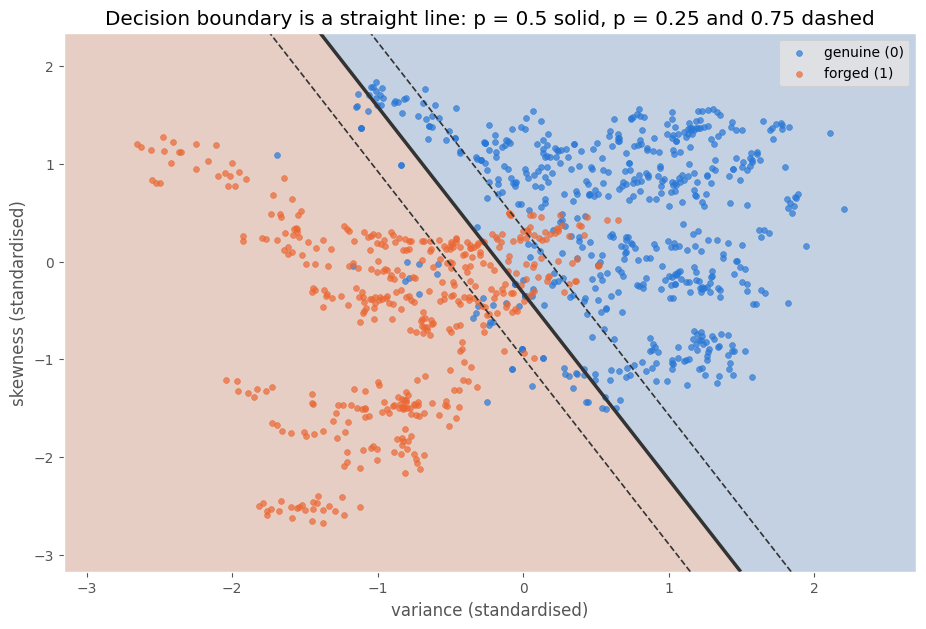

two-feature model: w = [-3.1716 -1.6642]  b = -0.5334
train accuracy: 0.8776
test accuracy:  0.8863


In [12]:
X_train_2 = X_train[:, :2]
X_test_2 = X_test[:, :2]

model_2 = Logistic_Regression(lr=0.5, n_iter=3000).fit(X_train_2, y_train)

pad = 0.5
xx = np.linspace(X_train_2[:, 0].min() - pad, X_train_2[:, 0].max() + pad, 300)
yy = np.linspace(X_train_2[:, 1].min() - pad, X_train_2[:, 1].max() + pad, 300)
gx, gy = np.meshgrid(xx, yy)
probs = model_2.predict_proba(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)

plt.figure(figsize=(11, 7))
plt.contourf(gx, gy, probs, levels=[0, 0.5, 1], colors=[BLUE, ORANGE], alpha=0.18)
plt.contour(gx, gy, probs, levels=[0.5], colors='#333333', linewidths=2.5)
plt.contour(gx, gy, probs, levels=[0.25, 0.75], colors='#333333',
            linewidths=1.2, linestyles='dashed')
plt.scatter(X_train_2[y_train == 0, 0], X_train_2[y_train == 0, 1],
            color=BLUE, s=18, alpha=0.7, label='genuine (0)')
plt.scatter(X_train_2[y_train == 1, 0], X_train_2[y_train == 1, 1],
            color=ORANGE, s=18, alpha=0.7, label='forged (1)')
plt.xlabel('variance (standardised)')
plt.ylabel('skewness (standardised)')
plt.title('Decision boundary is a straight line: p = 0.5 solid, p = 0.25 and 0.75 dashed')
plt.legend()
plt.grid(False)
plt.show()

print('two-feature model: w =', np.round(model_2.w, 4), ' b =', round(model_2.b, 4))
print('train accuracy:', round((model_2.predict(X_train_2) == y_train).mean(), 4))
print('test accuracy: ', round((model_2.predict(X_test_2) == y_test).mean(), 4))

## Confusion matrix

The cell runs the four-feature model over the test set and counts every (actual, predicted) pair
into a 2x2 matrix, then annotates each cell with its count. The diagonal is correct predictions,
the off-diagonal the two kinds of mistake: a genuine note flagged as forged (false positive) and a
forged note passed as genuine (false negative). The second is the costly one here, so recall on the
forged class is reported separately.

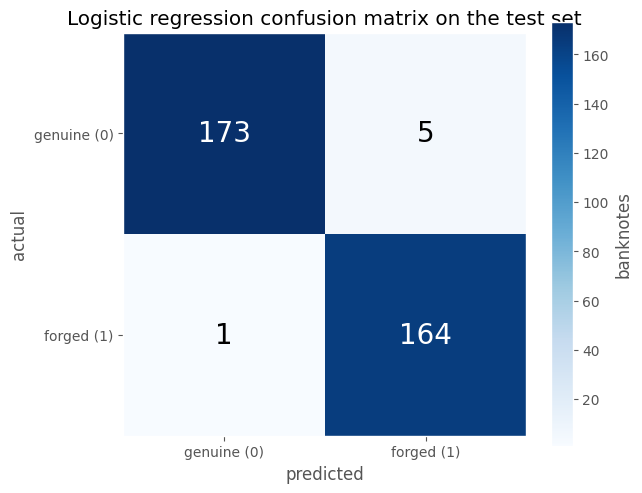

correct:  337 of 343
accuracy: 0.9825
forged notes passed as genuine (false negatives): 1
genuine notes flagged as forged (false positives): 5
recall on forged:    0.9939
precision on forged: 0.9704


In [13]:
predicted = model.predict(X_test)

matrix = np.zeros((2, 2), dtype=int)
for actual, pred in zip(y_test, predicted):
    matrix[actual, pred] += 1

labels = ['genuine (0)', 'forged (1)']

plt.figure(figsize=(6.5, 5.5))
plt.imshow(matrix, cmap='Blues')
plt.colorbar(label='banknotes')
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('Logistic regression confusion matrix on the test set')
for i in range(2):
    for j in range(2):
        colour = 'white' if matrix[i, j] > matrix.max() / 2 else 'black'
        plt.text(j, i, matrix[i, j], ha='center', va='center', fontsize=20, color=colour)
plt.grid(False)
plt.show()

true_neg, false_pos = matrix[0]
false_neg, true_pos = matrix[1]

print('correct: ', true_neg + true_pos, 'of', len(y_test))
print('accuracy:', round((true_neg + true_pos) / len(y_test), 4))
print('forged notes passed as genuine (false negatives):', false_neg)
print('genuine notes flagged as forged (false positives):', false_pos)
if true_pos + false_neg:
    print('recall on forged:   ', round(true_pos / (true_pos + false_neg), 4))
if true_pos + false_pos:
    print('precision on forged:', round(true_pos / (true_pos + false_pos), 4))

# Part 2 - Multi-class classification with the softmax

Two classes need one probability, because $P(y=0) = 1 - P(y=1)$. With $C$ classes the model has to
produce $C$ numbers that are each in $[0,1]$ and sum to 1.

The linear part becomes a matrix. Instead of one weight vector there are $C$ of them, stacked into
$W$ of shape (features, classes), and a bias vector $\mathbf{b}$ of length $C$, giving a vector of
scores - **logits** - per sample:

$$\mathbf{z} = W^\top\mathbf{x} + \mathbf{b}$$

## The softmax

$$P(y = c \mid \mathbf{x}) = \text{softmax}(\mathbf{z})_c = \frac{e^{z_c}}{\sum_{j=1}^{C} e^{z_j}}$$

Exponentiating makes every entry positive; dividing by the sum makes them add to 1. The largest
logit gets the largest probability, and the gaps between logits control how peaked the result is -
adding a constant to every logit changes nothing, only differences matter.

**It generalises the sigmoid.** Set $C = 2$:

$$P(y = 1 \mid \mathbf{x}) = \frac{e^{z_1}}{e^{z_0} + e^{z_1}}$$

Divide top and bottom by $e^{z_1}$:

$$= \frac{1}{1 + e^{z_0 - z_1}} = \frac{1}{1 + e^{-(z_1 - z_0)}} = \sigma(z_1 - z_0)$$

So two-class softmax is exactly the sigmoid applied to the difference of the two scores. Binary
logistic regression is the special case where that difference is parameterised directly by a single
$\mathbf{w}$ and $b$.

## Numerical stability

$e^{z}$ overflows in float64 once $z$ is above about 710, and returns `inf`, which makes the
division `nan`. The fix uses the shift-invariance above. For any constant $k$:

$$\frac{e^{z_c - k}}{\sum_j e^{z_j - k}}
  = \frac{e^{z_c}e^{-k}}{e^{-k}\sum_j e^{z_j}}
  = \frac{e^{z_c}}{\sum_j e^{z_j}}$$

The $e^{-k}$ cancels top and bottom, so the result is unchanged. Choosing $k = \max_j z_j$ makes
the largest exponent exactly $0$, so the biggest term is $e^0 = 1$ and every other is smaller.
Nothing can overflow. Underflow to zero is still possible for very negative shifted logits, but
that is harmless - those classes genuinely have negligible probability, and the denominator is at
least 1.

$$\text{softmax}(\mathbf{z}) = \text{softmax}\bigl(\mathbf{z} - \max_j z_j\bigr)$$

## Categorical cross-entropy

Labels are one-hot: $y_{ic} = 1$ if sample $i$ belongs to class $c$, else 0. The loss is

$$J = -\frac{1}{n}\sum_{i=1}^{n}\sum_{c=1}^{C} y_{ic} \log p_{ic}$$

Only the term for the true class survives the inner sum, so this is the average of
$-\log p_{i,\text{true}}$. For $C = 2$ it reduces to the binary cross-entropy from Part 1.

## The gradient

The same cancellation happens. Differentiating the softmax gives
$\partial p_c / \partial z_j = p_c(\delta_{cj} - p_j)$, and combining it with
$\partial J_i/\partial p_c = -y_{ic}/p_{ic}$ collapses (using $\sum_c y_{ic} = 1$) to

$$\frac{\partial J_i}{\partial z_j} = p_{ij} - y_{ij}$$

which is again just the error. In matrix form, with $P$ and $Y$ both of shape (n, C):

$$\nabla_W J = \frac{1}{n}X^\top(P - Y), \qquad
  \nabla_{\mathbf{b}} J = \frac{1}{n}\sum_{i=1}^{n} (\mathbf{p}_i - \mathbf{y}_i)$$

Identical in form to the binary case and to linear regression. This loss is convex too, so gradient
descent again converges to a global minimum.

## The softmax function

`softmax` takes a matrix `Z` of shape (n, C) and returns row-wise probabilities. It subtracts
`Z.max(axis=1, keepdims=True)` before exponentiating, for the reason given above. `keepdims=True`
keeps the result shaped (n, 1) so it broadcasts across the row.

The cell checks it on a plain vector of scores, on a vector containing 1000 (which overflows
without the shift), and confirms that adding a constant to every score leaves the output unchanged.

In [14]:
def softmax(Z):
    Z = np.atleast_2d(np.asarray(Z, dtype=float))
    shifted = Z - Z.max(axis=1, keepdims=True)
    e = np.exp(shifted)
    return e / e.sum(axis=1, keepdims=True)


scores = np.array([[2.0, 1.0, 0.1]])
print('scores:       ', scores.ravel())
print('probabilities:', np.round(softmax(scores).ravel(), 6))
print('row sum:      ', softmax(scores).sum())
print()

big = np.array([[1000.0, 999.0, 998.1]])
print('shifted by +998, same scores:', np.round(softmax(big).ravel(), 6))
print('matches the unshifted result:', np.allclose(softmax(big), softmax(scores)))
print('float64 exp overflows above about z = 709, and exp(1000) returns inf')
print()

shifted_check = softmax(scores + 7.5)
print('adding a constant changes nothing:', np.allclose(shifted_check, softmax(scores)))

scores:        [2.  1.  0.1]
probabilities: [0.659001 0.242433 0.098566]
row sum:       1.0

shifted by +998, same scores: [0.659001 0.242433 0.098566]
matches the unshifted result: True
float64 exp overflows above about z = 709, and exp(1000) returns inf

adding a constant changes nothing: True


## Turning scores into probabilities

The left panel puts the three raw scores next to the probabilities the softmax assigns them. The
scores are arbitrary real numbers; the bars on the right are all positive and sum to exactly 1, as
the annotation shows. The ordering is preserved - the largest score keeps the largest probability -
but the mapping is not linear, and the exponential exaggerates the gaps.

The right panel varies $z_0$ from $-6$ to $6$ while holding $z_1 = 1.0$ and $z_2 = 0.1$ fixed, and
plots all three output probabilities. As $z_0$ rises, class 0 takes probability away from the other
two and the three curves always sum to 1 vertically. The dashed line marks the point where class 0
overtakes class 1, which is exactly where $z_0 = z_1$.

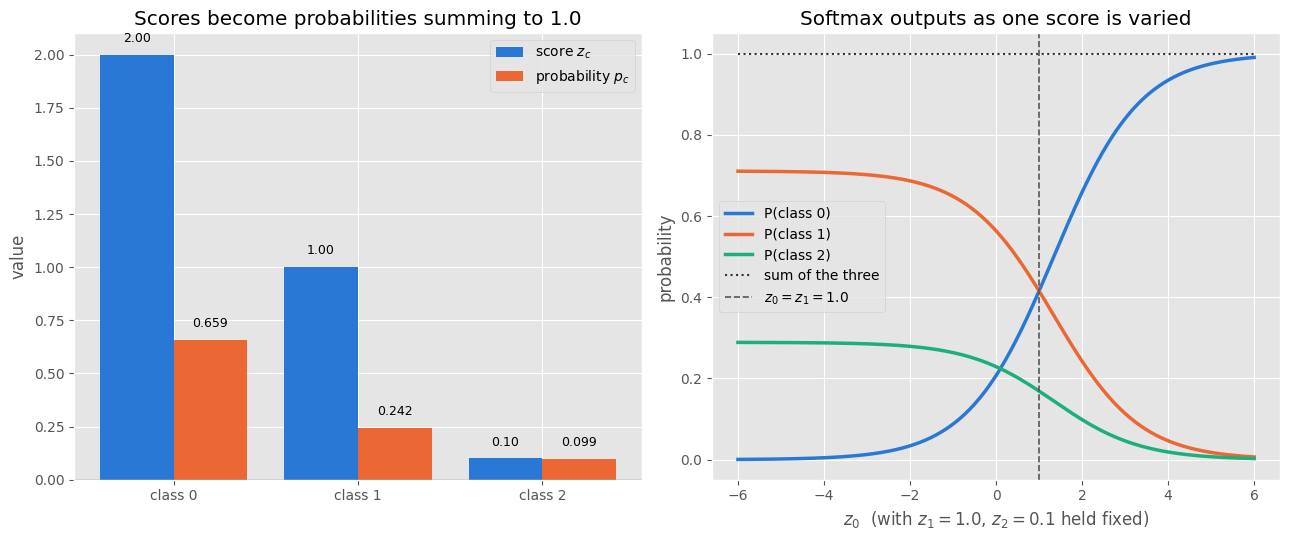

sweep rows all sum to 1: True


In [15]:
z_demo = np.array([2.0, 1.0, 0.1])
p_demo = softmax(z_demo).ravel()
positions = np.arange(3)
class_labels = ['class 0', 'class 1', 'class 2']

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

ax[0].bar(positions - 0.2, z_demo, width=0.4, color=BLUE, label='score $z_c$')
ax[0].bar(positions + 0.2, p_demo, width=0.4, color=ORANGE, label='probability $p_c$')
for i in range(3):
    ax[0].text(positions[i] - 0.2, z_demo[i] + 0.06, f'{z_demo[i]:.2f}',
               ha='center', fontsize=9)
    ax[0].text(positions[i] + 0.2, p_demo[i] + 0.06, f'{p_demo[i]:.3f}',
               ha='center', fontsize=9)
ax[0].axhline(0, color='#555555', linewidth=1)
ax[0].set_xticks(positions)
ax[0].set_xticklabels(class_labels)
ax[0].set_ylabel('value')
ax[0].set_title(f'Scores become probabilities summing to {p_demo.sum():.1f}')
ax[0].legend()

sweep = np.linspace(-6, 6, 400)
Z_sweep = np.column_stack([sweep, np.full_like(sweep, 1.0), np.full_like(sweep, 0.1)])
P_sweep = softmax(Z_sweep)

for c, colour in zip(range(3), [BLUE, ORANGE, AQUA]):
    ax[1].plot(sweep, P_sweep[:, c], color=colour, linewidth=2.5,
               label=f'P(class {c})')
ax[1].plot(sweep, P_sweep.sum(axis=1), color='#333333', linestyle=':', linewidth=1.5,
           label='sum of the three')
ax[1].axvline(1.0, color='#555555', linestyle='--', linewidth=1.2,
              label='$z_0 = z_1 = 1.0$')
ax[1].set_xlabel('$z_0$  (with $z_1 = 1.0$, $z_2 = 0.1$ held fixed)')
ax[1].set_ylabel('probability')
ax[1].set_title('Softmax outputs as one score is varied')
ax[1].legend(loc='center left')

plt.tight_layout()
plt.show()

print('sweep rows all sum to 1:', np.allclose(P_sweep.sum(axis=1), 1.0))

## Checking that softmax reduces to the sigmoid at C = 2

The cell builds 1000 random pairs of logits, runs them through `softmax`, and compares column 1
against `sigmoid(z1 - z0)`. The two agree to floating point precision, which is the identity
derived above. The maximum absolute difference is printed and asserted.

In [16]:
check_rng = np.random.RandomState(7)
Z2 = check_rng.uniform(-8, 8, size=(1000, 2))

P2 = softmax(Z2)
sig = sigmoid(Z2[:, 1] - Z2[:, 0])

gap = np.abs(P2[:, 1] - sig).max()

print('max |softmax(z)[1] - sigmoid(z1 - z0)| =', gap)
print('softmax rows sum to 1, max deviation:  ', np.abs(P2.sum(axis=1) - 1).max())

assert gap < 1e-12
assert np.allclose(P2.sum(axis=1), 1.0)
print()
print('C = 2 softmax is the sigmoid of the score difference: confirmed')

max |softmax(z)[1] - sigmoid(z1 - z0)| = 0.0
softmax rows sum to 1, max deviation:   2.220446049250313e-16

C = 2 softmax is the sigmoid of the score difference: confirmed


## Loading Iris

150 flowers, four measurements in centimetres, three species with 50 each. The target column holds
strings, so `np.unique` gives the sorted species names and `np.searchsorted` maps each row to its
index in that array, producing integer labels 0, 1, 2.

`np.eye(3)[y_iris]` one-hot encodes those integers: row $i$ of the identity matrix is the one-hot
vector for class $i$, so indexing the identity by the label array builds the whole $Y$ matrix at
once. The loss and the gradient both need $Y$ in that form.

The split and standardisation follow Part 1 exactly - a seeded permutation, 75/25, and `mu`/`sd`
from the training rows only.

In [17]:
iris = fetch_ucirepo(id=53)

iris_features = list(iris.data.features.columns)
X_iris_all = iris.data.features.values.astype(float)
species = iris.data.targets.values.ravel()

class_names = np.unique(species)
y_iris_all = np.searchsorted(class_names, species)

print('rows:    ', X_iris_all.shape[0])
print('features:', iris_features)
print('classes: ', list(class_names))
for c, name in enumerate(class_names):
    print(f'  {c} -> {name}: {(y_iris_all == c).sum()}')

irng = np.random.RandomState(42)
iorder = irng.permutation(len(X_iris_all))
icut = int(0.75 * len(X_iris_all))

Xi_train_raw = X_iris_all[iorder[:icut]]
Xi_test_raw = X_iris_all[iorder[icut:]]
yi_train = y_iris_all[iorder[:icut]]
yi_test = y_iris_all[iorder[icut:]]

imu = Xi_train_raw.mean(axis=0)
isd = Xi_train_raw.std(axis=0)
Xi_train = (Xi_train_raw - imu) / isd
Xi_test = (Xi_test_raw - imu) / isd

Yi_train = np.eye(len(class_names))[yi_train]
Yi_test = np.eye(len(class_names))[yi_test]

print()
print('train:', Xi_train.shape, ' test:', Xi_test.shape)
print('train class counts:', np.bincount(yi_train))
print('test class counts: ', np.bincount(yi_test))
print()
print('first five labels:      ', yi_train[:5])
print('first five one-hot rows:')
print(Yi_train[:5].astype(int))

rows:     150
features: ['sepal length', 'sepal width', 'petal length', 'petal width']
classes:  ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
  0 -> Iris-setosa: 50
  1 -> Iris-versicolor: 50
  2 -> Iris-virginica: 50

train: (112, 4)  test: (38, 4)
train class counts: [42 35 35]
test class counts:  [ 8 15 15]

first five labels:       [1 0 2 1 1]
first five one-hot rows:
[[0 1 0]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]]


## The Iris measurements

Two scatter plots of the raw measurements, coloured by species. Sepal length against sepal width on
the left, petal length against petal width on the right. Setosa is separated from the other two by
a wide gap in both views; versicolor and virginica overlap on the sepal measurements and are almost
- but not quite - separable on the petals. That is why the petal columns are the pair used for the
decision-region plot later.

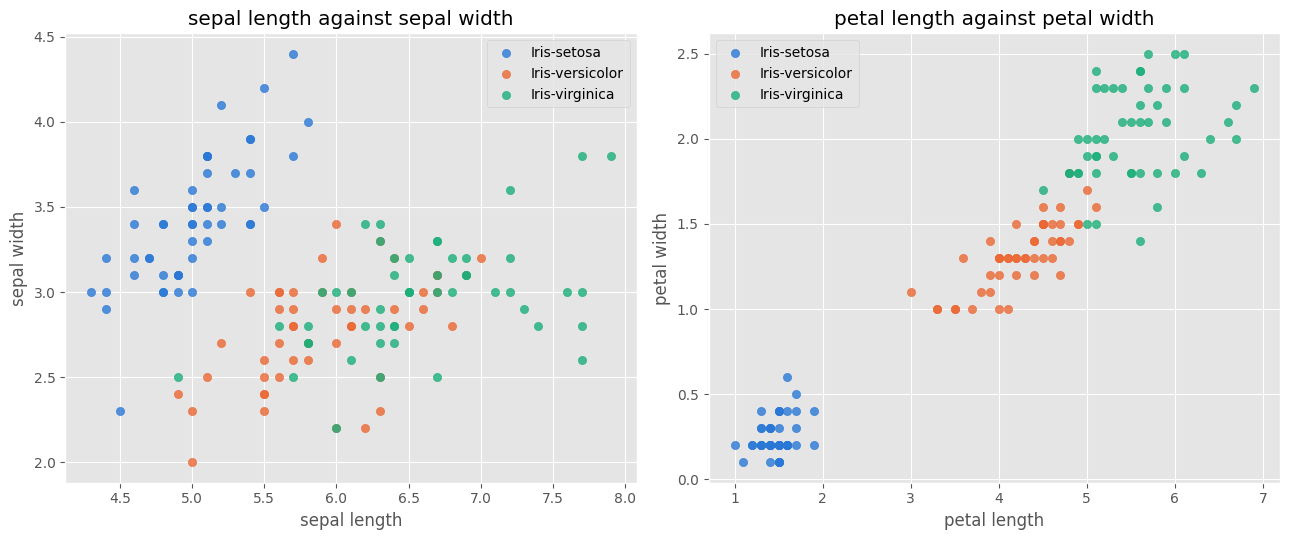

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
palette = [BLUE, ORANGE, AQUA]

for pair, panel in [((0, 1), ax[0]), ((2, 3), ax[1])]:
    for c, name in enumerate(class_names):
        rows = y_iris_all == c
        panel.scatter(X_iris_all[rows, pair[0]], X_iris_all[rows, pair[1]],
                      color=palette[c], s=35, alpha=0.8, label=name)
    panel.set_xlabel(iris_features[pair[0]])
    panel.set_ylabel(iris_features[pair[1]])
    panel.set_title(f'{iris_features[pair[0]]} against {iris_features[pair[1]]}')
    panel.legend()

plt.tight_layout()
plt.show()

## The Softmax_Regression class

The structure matches `Logistic_Regression`, with vectors promoted to matrices:

- `self.W` has shape (features, classes) and `self.b` has length `classes`, both starting at zero
- `Z = X @ self.W + self.b` gives an (n, C) matrix of logits, the bias broadcasting across rows
- `P = softmax(Z)` normalises each row
- `self.loss(Y, P)` is $-\frac{1}{n}\sum_i\sum_c y_{ic}\log p_{ic}$, again clipping `P` before the
  logarithm
- `error = P - Y` is the gradient with respect to the logits
- `self.W -= self.lr * (X.T @ error) / n` applies $\nabla_W J = \frac{1}{n}X^\top(P - Y)$
- `self.b -= self.lr * error.mean(axis=0)` applies the bias gradient

`predict_proba` returns the full (n, C) probability matrix and `predict` takes `argmax` along each
row. There is no threshold to choose in the multi-class case - the class with the highest
probability wins, and since the probabilities sum to 1 the winner always has at least $1/C$.

In [19]:
class Softmax_Regression:
    def __init__(self, lr=0.5, n_iter=3000):
        self.lr = lr
        self.n_iter = n_iter

    def loss(self, Y, P):
        P = np.clip(P, 1e-12, 1.0)
        return -np.mean(np.sum(Y * np.log(P), axis=1))

    def fit(self, X, Y):
        n, d = X.shape
        c = Y.shape[1]
        self.W = np.zeros((d, c))
        self.b = np.zeros(c)
        self.history = []

        for _ in range(self.n_iter):
            P = softmax(X @ self.W + self.b)
            self.history.append(self.loss(Y, P))

            error = P - Y
            self.W -= self.lr * (X.T @ error) / n
            self.b -= self.lr * error.mean(axis=0)

        self.history = np.array(self.history)
        return self

    def predict_proba(self, X):
        return softmax(X @ self.W + self.b)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

## Training on Iris

`fit` is called on the standardised training matrix and the one-hot `Yi_train`, for 3000 iterations
at `lr=0.5`. The cell reports the final loss and the train and test accuracy, then prints the
weight matrix - one column per species. Reading down a column shows what pushes a flower towards
that species: petal length and petal width dominate, and their signs flip between setosa and
virginica.

In [20]:
soft = Softmax_Regression(lr=0.5, n_iter=3000).fit(Xi_train, Yi_train)

soft_train_acc = (soft.predict(Xi_train) == yi_train).mean()
soft_test_acc = (soft.predict(Xi_test) == yi_test).mean()

print('final training loss:', round(float(soft.history[-1]), 6))
print('train accuracy:', round(soft_train_acc, 4))
print('test accuracy: ', round(soft_test_acc, 4))
print()
print('W  (rows = features, columns = species)')
header = ''.join(f'{n.split("-")[-1]:>14}' for n in class_names)
print(f"{'':<16}{header}")
for name, row in zip(iris_features, soft.W):
    print(f'{name:<16}' + ''.join(f'{v:>14.4f}' for v in row))
print(f"{'bias':<16}" + ''.join(f'{v:>14.4f}' for v in soft.b))

final training loss: 0.061148
train accuracy: 0.9821
test accuracy:  1.0

W  (rows = features, columns = species)
                        setosa    versicolor     virginica
sepal length           -2.5678        1.7118        0.8560
sepal width             2.7804       -0.6656       -2.1148
petal length           -4.1802       -1.7741        5.9542
petal width            -4.0770       -1.6703        5.7473
bias                    0.3828        5.1484       -5.5312


## Loss against iteration, and the learning rate

The left panel is the categorical cross-entropy over the 3000 iterations. It starts at
$-\log(1/3) \approx 1.0986$, which is what the loss must be when `W` and `b` are all zero: every
logit is 0, so the softmax gives each class exactly $1/3$. That number is a useful check that the
loss is implemented correctly.

The right panel refits at five learning rates. The pattern matches the binary case - the smallest
rate has barely moved off the starting value after 3000 iterations, and the largest converges
fastest.

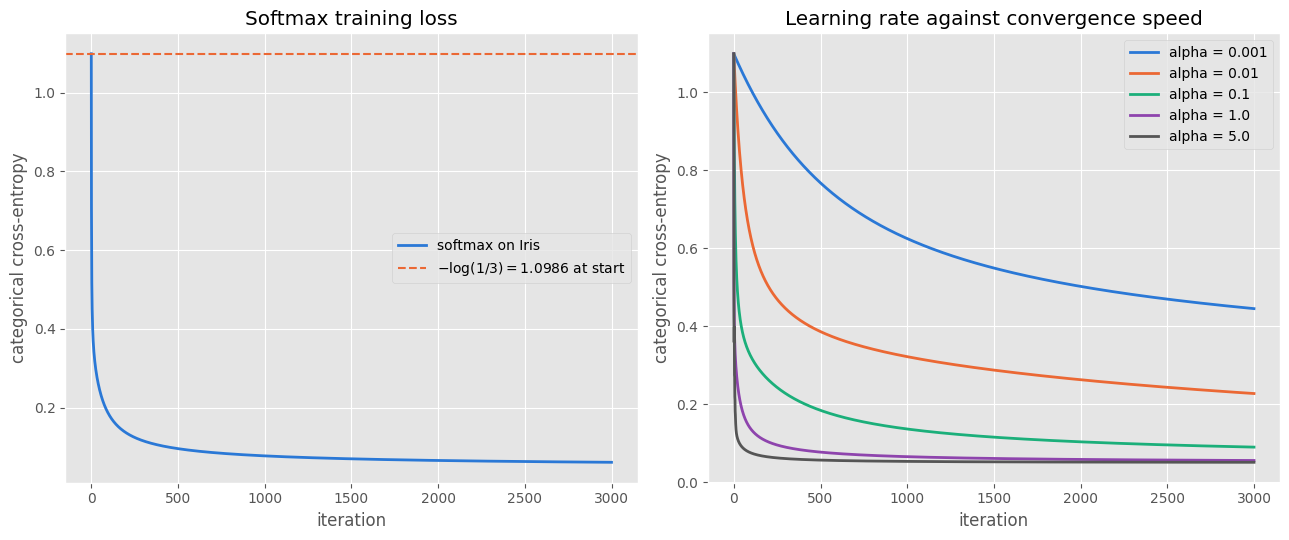

loss at iteration 0: 1.098612  -log(1/3) = 1.098612

   alpha    final loss   test accuracy
   0.001      0.445250          0.8158
    0.01      0.227614          0.9211
     0.1      0.090238          1.0000
     1.0      0.055960          1.0000
     5.0      0.051333          1.0000


In [21]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

ax[0].plot(soft.history, color=BLUE, linewidth=2, label='softmax on Iris')
ax[0].axhline(np.log(3), color=ORANGE, linestyle='--', linewidth=1.5,
              label=r'$-\log(1/3) = 1.0986$ at start')
ax[0].set_xlabel('iteration')
ax[0].set_ylabel('categorical cross-entropy')
ax[0].set_title('Softmax training loss')
ax[0].legend()

soft_lr_results = []
for rate, colour in zip(rates, colours):
    m = Softmax_Regression(lr=rate, n_iter=3000).fit(Xi_train, Yi_train)
    soft_lr_results.append((rate, m.history[-1], (m.predict(Xi_test) == yi_test).mean()))
    ax[1].plot(m.history, color=colour, linewidth=2, label=f'alpha = {rate}')

ax[1].set_xlabel('iteration')
ax[1].set_ylabel('categorical cross-entropy')
ax[1].set_title('Learning rate against convergence speed')
ax[1].legend()

plt.tight_layout()
plt.show()

print('loss at iteration 0:', round(float(soft.history[0]), 6),
      ' -log(1/3) =', round(float(np.log(3)), 6))
print()
print(f"{'alpha':>8}{'final loss':>14}{'test accuracy':>16}")
for rate, final, acc in soft_lr_results:
    print(f'{rate:>8}{final:>14.6f}{acc:>16.4f}')

## Three-class decision regions

The cell fits a second softmax model on the two petal columns only, then classifies a mesh over the
plane and colours each point by `argmax`. The three regions meet along straight lines, for the same
reason as in the binary case: the boundary between class $c$ and class $k$ is where $z_c = z_k$,
that is where $(\mathbf{w}_c - \mathbf{w}_k)^\top\mathbf{x} + (b_c - b_k) = 0$, which is a plane.
Multi-class does not buy any curvature - it just partitions the space with several straight cuts
meeting at a point.

Setosa is cleanly separated. The versicolor/virginica boundary passes through a region where the
two species genuinely overlap, so a handful of points sit on the wrong side, and no straight line
can do better on those two features.

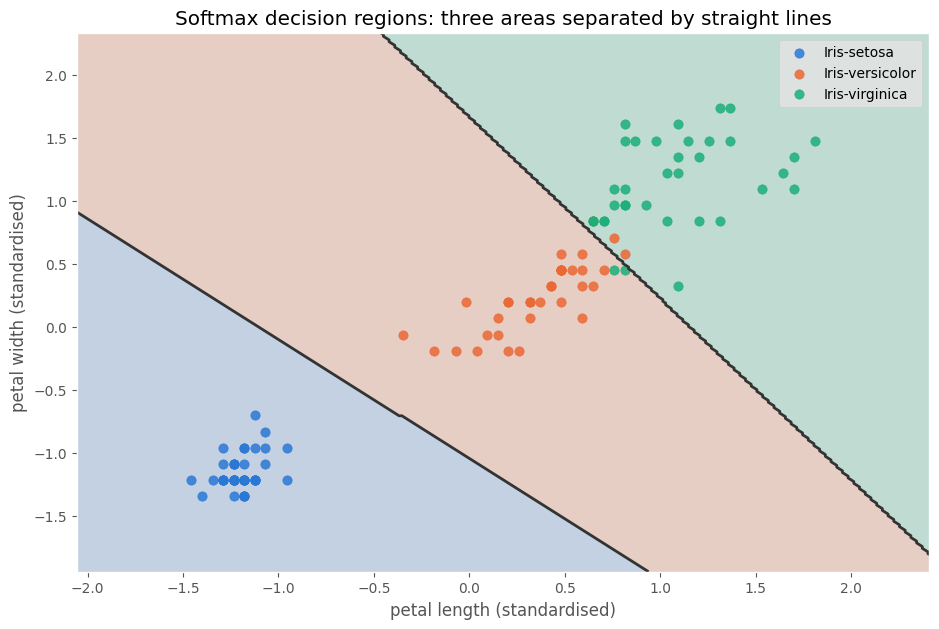

petal-only model
train accuracy: 0.9554
test accuracy:  0.9737


In [22]:
Xi_train_2 = Xi_train[:, 2:4]
Xi_test_2 = Xi_test[:, 2:4]

soft_2 = Softmax_Regression(lr=0.5, n_iter=3000).fit(Xi_train_2, Yi_train)

pad = 0.6
ixx = np.linspace(Xi_train_2[:, 0].min() - pad, Xi_train_2[:, 0].max() + pad, 300)
iyy = np.linspace(Xi_train_2[:, 1].min() - pad, Xi_train_2[:, 1].max() + pad, 300)
igx, igy = np.meshgrid(ixx, iyy)
regions = soft_2.predict(np.c_[igx.ravel(), igy.ravel()]).reshape(igx.shape)

plt.figure(figsize=(11, 7))
plt.contourf(igx, igy, regions, levels=[-0.5, 0.5, 1.5, 2.5],
             colors=[BLUE, ORANGE, AQUA], alpha=0.18)
plt.contour(igx, igy, regions, levels=[0.5, 1.5], colors='#333333', linewidths=2)
for c, name in enumerate(class_names):
    rows = yi_train == c
    plt.scatter(Xi_train_2[rows, 0], Xi_train_2[rows, 1], color=palette[c],
                s=45, alpha=0.85, label=name)
plt.xlabel(f'{iris_features[2]} (standardised)')
plt.ylabel(f'{iris_features[3]} (standardised)')
plt.title('Softmax decision regions: three areas separated by straight lines')
plt.legend()
plt.grid(False)
plt.show()

print('petal-only model')
print('train accuracy:', round((soft_2.predict(Xi_train_2) == yi_train).mean(), 4))
print('test accuracy: ', round((soft_2.predict(Xi_test_2) == yi_test).mean(), 4))

## Confusion matrix for the three classes

Same construction as before, now 3x3. Row $i$, column $j$ counts test flowers whose true species is
$i$ and predicted species is $j$. Any off-diagonal entry names exactly which species was confused
for which.

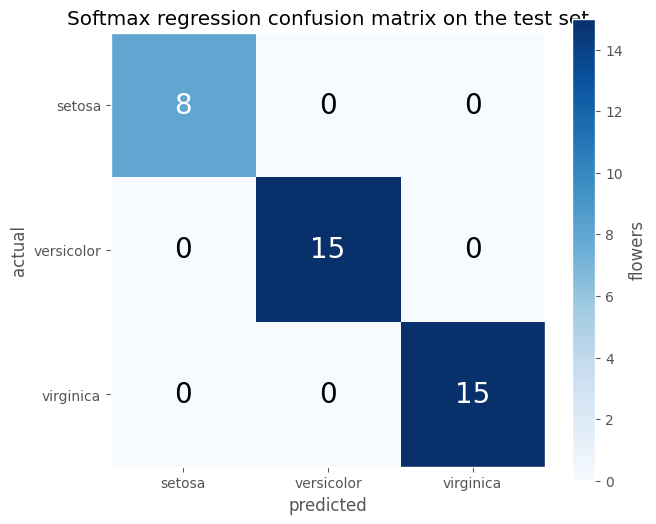

correct:  38 of 38
accuracy: 1.0

setosa       recall 8/8 = 1.0000
versicolor   recall 15/15 = 1.0000
virginica    recall 15/15 = 1.0000


In [23]:
soft_pred = soft.predict(Xi_test)
C = len(class_names)

imatrix = np.zeros((C, C), dtype=int)
for actual, pred in zip(yi_test, soft_pred):
    imatrix[actual, pred] += 1

short_names = [n.split('-')[-1] for n in class_names]

plt.figure(figsize=(7, 6))
plt.imshow(imatrix, cmap='Blues')
plt.colorbar(label='flowers')
plt.xticks(range(C), short_names)
plt.yticks(range(C), short_names)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('Softmax regression confusion matrix on the test set')
for i in range(C):
    for j in range(C):
        colour = 'white' if imatrix[i, j] > imatrix.max() / 2 else 'black'
        plt.text(j, i, imatrix[i, j], ha='center', va='center', fontsize=20, color=colour)
plt.grid(False)
plt.show()

print('correct: ', np.trace(imatrix), 'of', len(yi_test))
print('accuracy:', round(np.trace(imatrix) / len(yi_test), 4))
print()
for c, name in enumerate(short_names):
    total = imatrix[c].sum()
    if total:
        print(f'{name:<12} recall {imatrix[c, c]}/{total} = {imatrix[c, c] / total:.4f}')

## Predicted probabilities for individual flowers

The model does not just emit a label - it emits a full distribution over the three species. The
cell prints the probability row for the first eight test flowers alongside the predicted and actual
species, and the row sum. Every row sums to 1 to floating point precision.

Rows where one probability is near 1 are confident predictions; rows where two probabilities are
comparable are flowers sitting near a boundary, and those are where any mistakes appear.

In [24]:
probs_test = soft.predict_proba(Xi_test)

print('  ' + ''.join(f'{n:>13}' for n in short_names) + f"{'sum':>8}{'predicted':>13}{'actual':>13}")
for i in range(8):
    row = probs_test[i]
    line = '  ' + ''.join(f'{v:>13.6f}' for v in row)
    line += f'{row.sum():>8.4f}'
    line += f'{short_names[soft_pred[i]]:>13}{short_names[yi_test[i]]:>13}'
    print(line)

print()
print('every test row sums to 1:', np.allclose(probs_test.sum(axis=1), 1.0))
print('max deviation from 1:    ', float(np.abs(probs_test.sum(axis=1) - 1).max()))
print('mean probability given to the correct species:',
      round(float(probs_test[np.arange(len(yi_test)), yi_test].mean()), 4))

least = np.argmin(probs_test.max(axis=1))
print()
print('least confident test flower:', np.round(probs_test[least], 4),
      '-> predicted', short_names[soft_pred[least]], ', actual', short_names[yi_test[least]])

         setosa   versicolor    virginica     sum    predicted       actual
       0.000005     0.995352     0.004643  1.0000   versicolor   versicolor
       0.000000     0.001686     0.998314  1.0000    virginica    virginica
       0.999953     0.000047     0.000000  1.0000       setosa       setosa
       0.000000     0.008849     0.991151  1.0000    virginica    virginica
       0.000414     0.991243     0.008343  1.0000   versicolor   versicolor
       0.000000     0.025442     0.974558  1.0000    virginica    virginica
       0.000636     0.999348     0.000016  1.0000   versicolor   versicolor
       0.003035     0.992121     0.004844  1.0000   versicolor   versicolor

every test row sums to 1: True
max deviation from 1:     2.220446049250313e-16
mean probability given to the correct species: 0.9741

least confident test flower: [1.000e-04 2.577e-01 7.422e-01] -> predicted virginica , actual virginica


## Checks

The cell asserts the properties the derivations above depend on: softmax rows sum to 1 for both
the demo matrices and the trained model's output, the two-class softmax equals the sigmoid of the
score difference, the sigmoid stays strictly inside $(0,1)$ and satisfies
$\sigma(-z) = 1 - \sigma(z)$, its derivative matches a central difference, and both training losses
decreased monotonically.

The sigmoid range is checked over $z \in [-30, 30]$ rather than something wider because float64
carries only about 16 digits: past roughly $z = 36$, $1 - \sigma(z)$ falls below machine epsilon
and $\sigma(z)$ rounds to exactly $1.0$. The mathematics says it never reaches 1, the arithmetic
disagrees, and that is exactly why `loss` clips before taking a logarithm.

In [25]:
# softmax rows sum to 1
assert np.allclose(softmax(np.random.RandomState(1).uniform(-50, 50, (500, 4))).sum(axis=1), 1.0)
assert np.allclose(soft.predict_proba(Xi_test).sum(axis=1), 1.0)
assert np.allclose(soft.predict_proba(Xi_train).sum(axis=1), 1.0)

# C = 2 softmax is the sigmoid
Zc = np.random.RandomState(2).uniform(-30, 30, (500, 2))
assert np.abs(softmax(Zc)[:, 1] - sigmoid(Zc[:, 1] - Zc[:, 0])).max() < 1e-12

# sigmoid properties (float64 rounds sigma(z) to exactly 1.0 past about z = 36)
zt = np.linspace(-30, 30, 1001)
st = sigmoid(zt)
assert np.all((st > 0) & (st < 1))
assert np.allclose(sigmoid(-zt), 1 - st)
assert np.isclose(float(sigmoid(0.0)), 0.5)

# derivative identity against a numerical difference
h = 1e-5
numeric = (sigmoid(zt + h) - sigmoid(zt - h)) / (2 * h)
assert np.abs(numeric - st * (1 - st)).max() < 1e-6

# losses decreased
assert model.history[-1] < model.history[0]
assert soft.history[-1] < soft.history[0]
assert np.all(np.diff(model.history) <= 1e-12)
assert np.all(np.diff(soft.history) <= 1e-12)

print('all checks passed')
print()
print('banknote, variance only   - test accuracy', round(test_acc_v, 4))
print('banknote, all four        - test accuracy', round(test_acc, 4))
print('banknote, two features    - test accuracy',
      round((model_2.predict(X_test_2) == y_test).mean(), 4))
print('iris softmax, all four    - test accuracy', round(soft_test_acc, 4))
print('iris softmax, petals only - test accuracy',
      round((soft_2.predict(Xi_test_2) == yi_test).mean(), 4))
print()
print('final binary cross-entropy:     ', round(float(model.history[-1]), 6))
print('final categorical cross-entropy:', round(float(soft.history[-1]), 6))

all checks passed

banknote, variance only   - test accuracy 0.8455
banknote, all four        - test accuracy 0.9825
banknote, two features    - test accuracy 0.8863
iris softmax, all four    - test accuracy 1.0
iris softmax, petals only - test accuracy 0.9737

final binary cross-entropy:      0.031986
final categorical cross-entropy: 0.061148


## Summary

Both halves of this notebook are the same model. A linear score is computed, squashed into
probabilities, and compared against the labels with a cross-entropy loss. The squashing function is
the sigmoid when there are two classes and the softmax when there are more, and the second contains
the first: at $C = 2$, $\text{softmax}(\mathbf{z})_1 = \sigma(z_1 - z_0)$, confirmed numerically
above.

What carries across all of it:

- The sigmoid $\sigma(z) = 1/(1+e^{-z})$ turns an unbounded score into a probability, and its
  derivative $\sigma(1-\sigma)$ is what makes the log-loss gradient collapse to $p - y$.
- The model is linear in the **log-odds**, $\log\frac{p}{1-p} = \mathbf{w}^\top\mathbf{x} + b$, so
  each $w_j$ multiplies the odds by $e^{w_j}$ per unit of $x_j$.
- Log loss is used rather than squared error because it is convex under the sigmoid and does not
  suffer the vanishing gradient that $\sigma'(z)$ would otherwise introduce.
- The softmax must subtract the row maximum before exponentiating; the constant cancels top and
  bottom so the result is unchanged, and nothing overflows.
- Every gradient here has the form $\frac{1}{n}X^\top(\text{prediction} - \text{target})$, the same
  expression as least-squares linear regression.
- The decision boundary is always a straight line, plane or hyperplane. The banknote classes are
  close to linearly separable so this costs almost nothing; the versicolor/virginica overlap on
  Iris is where it bites.